# LSTM — Multi Seed Walk Forward

In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torch.nn.utils.rnn import pack_padded_sequence
from scipy import stats

SEED = 42
DATA_PATH = Path("../Merged_Dataset_yoy.csv")
PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
DEFAULT_LOOKBACK_DAYS = 365
MAX_EPOCHS = 100
PATIENCE = 15
TEST_YEAR_CUTOFF = 2023
SYMLOG_CAP = float(np.log1p(3.0))
N_SEEDS_WF = 5
WALK_FORWARD_YEARS = [2019, 2020, 2021, 2022, 2023, 2024, 2025]

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, torch.get_num_threads() // 2))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")
print(f"Walk-forward test years: {WALK_FORWARD_YEARS}")
print(f"Seeds per fold: {N_SEEDS_WF}")
print(f"Total model builds: {len(WALK_FORWARD_YEARS) * N_SEEDS_WF * 2}  (trained + untrained per fold-seed)")

Using device: cuda
Walk-forward test years: [2019, 2020, 2021, 2022, 2023, 2024, 2025]
Seeds per fold: 5
Total model builds: 70  (trained + untrained per fold-seed)


## Data Loading (Improved Pipeline)

In [9]:
def load_and_prepare_yoy_data(data_path: Path, lookback_days: int = 365):
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        df = pd.read_csv("Merged_Dataset_yoy.csv")

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
    df["year"] = df["Date"].dt.year

    df["Close_logret"] = df.groupby("Company")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    df["Volume_log"] = np.log1p(df["Volume"].clip(lower=0))

    df["has_targets"] = df[PREDICTION_TARGETS].notna().any(axis=1)
    year_end_records = df[df["has_targets"]].copy()
    prior_static_cols = [
        "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
        "Leverage", "Cash_Ratio", "Size_SL",
        "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL",
    ]
    current_year_cols = [
        "Total_Assets", "Total_Debt", "Cash",
        "Net_Sales", "Operating_Expenses", "FCF_Per_Share",
    ]
    static_cols = ["MC_MIB", "MC_MID", "MC_SMALL", "Sector"]
    exclude_cols = ({"Date", "Company", "year", "has_targets"}
                    | set(PREDICTION_TARGETS) | set(prior_static_cols)
                    | set(current_year_cols) | set(static_cols))
    feature_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    sequences = []
    for company in df["Company"].unique():
        company_records = year_end_records[year_end_records["Company"] == company].copy()
        company_data = df[df["Company"] == company].copy()

        for _, year_end_row in company_records.iterrows():
            year = int(year_end_row["year"])
            year_end_date = year_end_row["Date"]

            prior_year_records = year_end_records[
                (year_end_records["Company"] == company) & (year_end_records["year"] == year - 1)
            ]
            if prior_year_records.empty:
                continue

            prior_row = prior_year_records.iloc[0]
            window_start = year_end_date - pd.Timedelta(days=lookback_days)
            window = company_data[(company_data["Date"] > window_start) & (company_data["Date"] <= year_end_date)].copy()

            if len(window) < 200:
                continue

            window[feature_cols] = window[feature_cols].ffill().bfill()
            if window[feature_cols].isna().any().any():
                continue

            static_cols = ["MC_MIB", "MC_MID", "MC_SMALL",
                           "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
                           "Leverage", "Cash_Ratio", "Size_SL",
                           "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL"]
            static_data = window[static_cols].iloc[-1].to_numpy(dtype=np.float32)
            sector_str = str(window["Sector"].iloc[-1])

            sequences.append({
                "company": company, "year": year, "year_end_date": year_end_date,
                "window_data": window[feature_cols].to_numpy(dtype=np.float32),
                "static_data": static_data,
                "sector": sector_str,
                **{f"current_{t.lower()}": year_end_row[t] for t in PREDICTION_TARGETS},
                **{f"prior_{t.lower()}": prior_row[t] for t in PREDICTION_TARGETS},
            })

    data_records = []
    for seq in sequences:
        for target_name in PREDICTION_TARGETS:
            current_val = seq[f"current_{target_name.lower()}"]
            prior_val = seq[f"prior_{target_name.lower()}"]
            if pd.isna(current_val) or pd.isna(prior_val):
                continue
            label_value = (current_val - prior_val) / (np.abs(prior_val) + 1e-8)
            data_records.append({
                "company": seq["company"], "year": seq["year"], "year_end_date": seq["year_end_date"],
                "target": target_name, "label_value": label_value,
                "window_data": seq["window_data"],
                "static_data": seq["static_data"],
                "sector": seq["sector"],
            })

    return pd.DataFrame(data_records), feature_cols

data_df, feature_cols = load_and_prepare_yoy_data(DATA_PATH, lookback_days=DEFAULT_LOOKBACK_DAYS)
print(f"Raw records: {len(data_df)}, features: {len(feature_cols)}")

Raw records: 6715, features: 34


In [10]:
SELECTED_FEATURES = [
    'Close_logret', 'Volume_log',
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume',
    'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close',
    'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv',
    'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom',
    'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume'
]
STATIC_FEATURES = ['MC_MIB', 'MC_MID', 'MC_SMALL']
selected_indices = [feature_cols.index(f) for f in SELECTED_FEATURES]
print(f"Selected temporal features ({len(SELECTED_FEATURES)}) and static ({len(STATIC_FEATURES)}).")

WINSOR_CAP = 3.0
SECTOR_LIST = sorted(data_df["sector"].unique())
SECTOR_TO_IDX = {s: i for i, s in enumerate(SECTOR_LIST)}
N_SECTORS = len(SECTOR_LIST)

def sector_onehot(sector_str):
    v = np.zeros(N_SECTORS, dtype=np.float32)
    if sector_str in SECTOR_TO_IDX:
        v[SECTOR_TO_IDX[sector_str]] = 1.0
    return v

def build_full_static(static_data_arr, sector_str):
    mc_and_prior = np.asarray(static_data_arr, dtype=np.float32)
    sector_oh = sector_onehot(sector_str)
    return np.concatenate([mc_and_prior[:3], sector_oh, mc_and_prior[3:]]).astype(np.float32)

static_nan_mask = data_df["static_data"].apply(
    lambda a: bool(np.isnan(np.asarray(a, dtype=float)).any())
)
data_df_imp_base = data_df.loc[~static_nan_mask].copy().reset_index(drop=True)
data_df_imp_base["static_data"] = data_df_imp_base.apply(
    lambda r: build_full_static(r["static_data"], r["sector"]), axis=1
)
print(f"Dropped {len(data_df) - len(data_df_imp_base)} samples missing prior fundamentals; "
      f"{len(data_df_imp_base)} remaining.")

data_df_imp = data_df_imp_base.copy()
sym_lab = data_df_imp["label_value"].to_numpy()
raw_ratio = np.sign(sym_lab) * np.expm1(np.abs(sym_lab))
capped = np.clip(raw_ratio, -WINSOR_CAP, WINSOR_CAP)
data_df_imp["label_value"] = (np.sign(capped) * np.log1p(np.abs(capped))).astype(np.float32)
n_capped = int(np.sum(np.abs(raw_ratio) > WINSOR_CAP))
print(f"Winsor: capped {n_capped}/{len(raw_ratio)} ({100.0*n_capped/len(raw_ratio):.2f}%) at +/-{int(WINSOR_CAP)}.")

STATIC_DIM_IMP = 3 + N_SECTORS + 9
NEW_STATIC_SLICE = slice(3 + N_SECTORS, 3 + N_SECTORS + 9)
print(f"STATIC_DIM_IMP={STATIC_DIM_IMP}, slice={NEW_STATIC_SLICE.start}:{NEW_STATIC_SLICE.stop}")
print(f"Years available: {sorted(int(y) for y in data_df_imp['year'].unique())}")

Selected temporal features (26) and static (3).
Dropped 970 samples missing prior fundamentals; 5745 remaining.
Winsor: capped 1018/5745 (17.72%) at +/-3.
STATIC_DIM_IMP=22, slice=13:22
Years available: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


/tmp/ipykernel_646/1345861463.py:41: RuntimeWarning: overflow encountered in expm1
  raw_ratio = np.sign(sym_lab) * np.expm1(np.abs(sym_lab))


## Model, Dataset, Helpers

In [11]:
class ShallowLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = 1,
                 dropout: float = 0.0, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed_x)
        hidden = self.dropout(hn[-1])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1:
            logits = logits.squeeze(-1)
        return logits


def extract_mtl_df(df: pd.DataFrame) -> pd.DataFrame:
    mtl_records = []
    for (company, year), group in df.groupby(["company", "year"]):
        window_data = group.iloc[0]["window_data"]
        year_end_date = group.iloc[0]["year_end_date"]
        static_data = group.iloc[0]["static_data"]
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                label_value[i] = t_row.iloc[0]["label_value"]
        mtl_records.append({
            "company": company, "year": year, "year_end_date": year_end_date,
            "window_data": window_data, "static_data": static_data,
            "sector": group.iloc[0]["sector"] if "sector" in group.iloc[0].index else "",
            "label_value": label_value
        })
    return pd.DataFrame(mtl_records)


class YoYDatasetMTL(Dataset):
    def __init__(self, data_df, scaler, feature_indices, window_size=None):
        self.data_df = data_df.reset_index(drop=True)
        self.scaler = scaler
        self.feature_indices = feature_indices
        self.window_size = window_size

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        window = row["window_data"][:, self.feature_indices].copy()
        if self.window_size is not None:
            window = window[-self.window_size:]
        if self.scaler:
            window = self.scaler.transform(window)
        static = row["static_data"].astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return (
            torch.from_numpy(window),
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            len(window),
        )


def collate_fn_mtl(batch):
    batch.sort(key=lambda x: x[4], reverse=True)
    sequences = [x[0] for x in batch]
    statics = torch.stack([x[1] for x in batch])
    targets = torch.stack([x[2] for x in batch])
    masks = torch.stack([x[3] for x in batch])
    lengths = torch.tensor([x[4] for x in batch])
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, masks, statics, lengths


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)


def make_robust_scaler(train_df, feature_indices):
    sc = RobustScaler()
    train_windows = np.vstack([row[:, feature_indices] for row in train_df["window_data"]])
    sc.fit(train_windows)
    return sc


def fit_static_scaler(mtl_df, new_slice=NEW_STATIC_SLICE):
    arr = np.vstack(mtl_df["static_data"].values).astype(np.float32)
    return RobustScaler().fit(arr[:, new_slice])


def apply_static_scaler(mtl_df, sc, new_slice=NEW_STATIC_SLICE):
    df = mtl_df.copy().reset_index(drop=True)
    arr = np.vstack(df["static_data"].values).astype(np.float32)
    arr[:, new_slice] = sc.transform(arr[:, new_slice]).astype(np.float32)
    df["static_data"] = [arr[i] for i in range(len(arr))]
    return df


def evaluate_loader(model, loader):
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for bx, by, bmask, bstatic, lengths in loader:
            logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
            all_preds.append(logits.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())
    if not all_preds:
        return None
    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    y_pred = np.clip(y_pred, -SYMLOG_CAP, SYMLOG_CAP)
    y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
    y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
    mask = np.vstack(all_masks)
    res = {}
    all_errors = []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        res[t] = np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
        all_errors.extend(np.abs(y_pred[m, i] - y_true[m, i]).tolist())
    res["Overall"] = np.mean(all_errors) if all_errors else None
    return res

In [ ]:
def build_loaders_wf(train_df, val_df, test_df, params, sample_alpha=0.0):
    mtl_train = extract_mtl_df(train_df)
    mtl_val   = extract_mtl_df(val_df)
    mtl_test  = extract_mtl_df(test_df)

    temp_sc = make_robust_scaler(mtl_train, selected_indices)
    stat_sc = fit_static_scaler(mtl_train)

    train_ds = YoYDatasetMTL(apply_static_scaler(mtl_train, stat_sc), temp_sc, selected_indices)
    val_ds   = YoYDatasetMTL(apply_static_scaler(mtl_val,   stat_sc), temp_sc, selected_indices)
    test_ds  = YoYDatasetMTL(apply_static_scaler(mtl_test,  stat_sc), temp_sc, selected_indices)

    if sample_alpha > 0:
        ref_year = int(test_df["year"].max())
        years = mtl_train["year"].values
        weights = np.exp(-sample_alpha * (ref_year - years))
        sampler = WeightedRandomSampler(
            weights=torch.from_numpy(weights).double(),
            num_samples=len(weights), replacement=True,
        )
        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], sampler=sampler, collate_fn=collate_fn_mtl)
    else:
        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True, collate_fn=collate_fn_mtl)

    val_loader   = DataLoader(val_ds,   batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    test_loader  = DataLoader(test_ds,  batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    model = ShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS), params.get("dropout", 0.0), static_dim=STATIC_DIM_IMP).to(DEVICE)

    return model, train_loader, val_loader, test_loader



def train_with_val_es(model, train_loader, val_loader, test_loader, optimizer, patience=PATIENCE, max_epochs=MAX_EPOCHS, grad_clip=5.0, verbose=False):
    criterion = nn.L1Loss(reduction='none')
    best_val_mae = float("inf")
    best_val_epoch = 0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for bx, by, bmask, bstatic, lengths in train_loader:
            bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(bx, lengths, bstatic)
            loss_m = criterion(logits, by)
            mask_f = bmask.to(loss_m.dtype)
            loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)

            if loss.requires_grad:
                loss.backward()
                if grad_clip and grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
                optimizer.step()

        model.eval()
        va_res = evaluate_loader(model, val_loader)
        te_res = evaluate_loader(model, test_loader)

        if va_res["Overall"] < best_val_mae:
            best_val_mae = va_res["Overall"]
            best_val_epoch = epoch
            best_test_at_best_val = te_res["Overall"]
            best_state = {name: t.detach().cpu().clone() for name, t in model.state_dict().items()}
            epochs_no_improve = 0

        else:
            epochs_no_improve += 1

        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f"    ep{epoch:3d} val={va_res['Overall']:.4f} test={te_res['Overall']:.4f}")

        if epochs_no_improve >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val_epoch, best_val_mae, best_test_at_best_val


## Walk-Forward Loop

For each test year Y in [2019..2024], with val_year = Y−1 and train ≤ Y−2:
- 5 seeds × {untrained eval, train with val ES, test at val-best epoch}
- Same CONFIG as the diagnostic notebook (hidden=128, lr=1e-3, batch=32, no reg)
- This is the most honest walk-forward: no test-set selection, no leakage from the test year

In [13]:
CONFIG = {
    "hidden_size": 128,
    "batch_size": 32,
    "lr": 1e-3,
    "dropout": 0.0,
    "weight_decay": 0.0,
}

In [14]:
wf_rows = []

for ty in WALK_FORWARD_YEARS:
    val_year = ty - 1
    train_end_year = ty - 2
    train_df = data_df_imp[data_df_imp["year"] <= train_end_year].copy()
    val_df   = data_df_imp[data_df_imp["year"] == val_year].copy()
    test_df  = data_df_imp[data_df_imp["year"] == ty].copy()
    n_train, n_val, n_test = len(train_df), len(val_df), len(test_df)
    print(f"\n=== Test year {ty} | train ≤{train_end_year} ({n_train}), val={val_year} ({n_val}), test={ty} ({n_test}) ===")

    for si in range(N_SEEDS_WF):
        seed = SEED + si
        set_seed(seed)
        model, train_loader, val_loader, test_loader = build_loaders_wf(train_df, val_df, test_df, CONFIG)
        untrained_res = evaluate_loader(model, test_loader)
        untrained_mae = untrained_res["Overall"]

        optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"],
                                     weight_decay=CONFIG.get("weight_decay", 0.0))
        best_val_ep, best_val_mae, test_at_best_val = train_with_val_es(
            model, train_loader, val_loader, test_loader, optimizer,
            patience=PATIENCE, max_epochs=MAX_EPOCHS, grad_clip=5.0, verbose=False,
        )
        test_per_target = evaluate_loader(model, test_loader)
        delta = test_at_best_val - untrained_mae
        wf_rows.append({
            "test_year": ty, "val_year": val_year, "train_end_year": train_end_year,
            "n_train": n_train, "n_val": n_val, "n_test": n_test,
            "seed": seed, "val_best_epoch": best_val_ep,
            "untrained_mae": untrained_mae, "trained_mae": test_at_best_val,
            "delta": delta,
            "untrained_ebitda": untrained_res["EBITDA"],
            "untrained_ni":     untrained_res["Net_Income"],
            "untrained_roa":    untrained_res["ROA"],
            "trained_ebitda":   test_per_target["EBITDA"],
            "trained_ni":       test_per_target["Net_Income"],
            "trained_roa":      test_per_target["ROA"],
        })
        print(f"  seed {seed}: val_best_ep={best_val_ep:3d}  untrained={untrained_mae:.4f}  "
              f"trained={test_at_best_val:.4f}  delta={delta:+.4f}")

df_wf = pd.DataFrame(wf_rows)
df_wf.to_csv("walk_forward_multi_seed_per_target_results.csv", index=False)
print(f"\nSaved walk_forward_multi_seed_per_target_results.csv ({len(df_wf)} rows)")



=== Test year 2019 | train ≤2017 (2364), val=2018 (375), test=2019 (376) ===
  seed 42: val_best_ep= 24  untrained=0.9395  trained=0.9125  delta=-0.0269
  seed 43: val_best_ep= 19  untrained=0.9048  trained=0.9191  delta=+0.0143
  seed 44: val_best_ep= 20  untrained=0.9137  trained=0.8936  delta=-0.0200
  seed 45: val_best_ep= 20  untrained=0.9553  trained=0.9215  delta=-0.0338
  seed 46: val_best_ep= 32  untrained=0.9311  trained=0.9690  delta=+0.0379

=== Test year 2020 | train ≤2018 (2739), val=2019 (376), test=2020 (395) ===
  seed 42: val_best_ep= 12  untrained=1.1858  trained=1.1478  delta=-0.0380
  seed 43: val_best_ep=  9  untrained=1.1198  trained=1.1279  delta=+0.0080
  seed 44: val_best_ep=  7  untrained=1.1105  trained=1.1284  delta=+0.0179
  seed 45: val_best_ep= 34  untrained=1.1571  trained=1.1541  delta=-0.0030
  seed 46: val_best_ep=  8  untrained=1.1173  trained=1.1409  delta=+0.0236

=== Test year 2021 | train ≤2019 (3115), val=2020 (395), test=2021 (419) ===
  seed

## Aggregated Results per Test Year

In [15]:
agg = df_wf.groupby("test_year").agg(
    n_test=("n_test", "first"),
    n_train=("n_train", "first"),
    val_best_epoch_mean=("val_best_epoch", "mean"),
    val_best_epoch_std=("val_best_epoch", "std"),
    untrained_mean=("untrained_mae", "mean"),
    untrained_std=("untrained_mae", "std"),
    trained_mean=("trained_mae", "mean"),
    trained_std=("trained_mae", "std"),
    delta_mean=("delta", "mean"),
    delta_std=("delta", "std"),
).reset_index()
agg["pct_improvement"] = 100.0 * agg["delta_mean"] / agg["untrained_mean"]
print("Walk-forward multi-seed summary (Overall MAE, real space):")
display(agg.round(4))

Walk-forward multi-seed summary (Overall MAE, real space):


,test_year,n_test,n_train,val_best_epoch_mean,val_best_epoch_std,untrained_mean,untrained_std,trained_mean,trained_std,delta_mean,delta_std,pct_improvement
0,2019,376,2364,23.0,5.3852,0.9289,0.0202,0.9232,0.0279,-0.0057,0.0306,-0.6154
1,2020,395,2739,14.0,11.3358,1.1381,0.0323,1.1398,0.0116,0.0017,0.0244,0.1485
2,2021,419,3115,13.2,11.1669,1.3548,0.0860,1.2013,0.0331,-0.1534,0.0838,-11.3253
3,2022,438,3510,35.6,7.9561,0.9564,0.0227,0.9059,0.0270,-0.0505,0.0482,-5.2794
4,2023,459,3929,29.0,15.6844,0.9010,0.0086,0.8994,0.0363,-0.0016,0.0394,-0.1745
5,2024,469,4367,13.0,3.3166,0.8149,0.0173,0.7866,0.0091,-0.0283,0.0229,-3.4734
6,2025,450,4826,22.8,6.7231,0.8089,0.0178,0.7833,0.0252,-0.0257,0.0338,-3.1742


In [16]:
print("Per-year paired t-test (trained vs untrained, paired by seed):")
print(f"{'Year':<6}{'n':<5}{'mean_delta':>12}{'std_delta':>11}{'t-stat':>10}{'p-value':>10}{'sig?':>8}")
sig_rows = []
for ty, sub in df_wf.groupby("test_year"):
    deltas = sub["delta"].values
    t_stat, p_val = stats.ttest_1samp(deltas, popmean=0.0)
    sig = "Y" if p_val < 0.05 else "n"
    sig_rows.append({"test_year": ty, "mean_delta": deltas.mean(),
                     "std_delta": deltas.std(ddof=1), "t_stat": t_stat,
                     "p_value": p_val, "significant": sig})
    print(f"{ty:<6}{len(sub):<5}{deltas.mean():+12.4f}{deltas.std(ddof=1):>11.4f}"
          f"{t_stat:>10.3f}{p_val:>10.4f}{sig:>8}")
df_sig = pd.DataFrame(sig_rows)
print()
n_sig = (df_sig["significant"] == "Y").sum()
print(f"{n_sig}/{len(df_sig)} years show a statistically significant improvement (p<0.05).")

Per-year paired t-test (trained vs untrained, paired by seed):
Year  n      mean_delta  std_delta    t-stat   p-value    sig?
2019  5         -0.0057     0.0306    -0.417    0.6978       n
2020  5         +0.0017     0.0244     0.155    0.8844       n
2021  5         -0.1534     0.0838    -4.093    0.0149       Y
2022  5         -0.0505     0.0482    -2.341    0.0793       n
2023  5         -0.0016     0.0394    -0.089    0.9332       n
2024  5         -0.0283     0.0229    -2.769    0.0504       n
2025  5         -0.0257     0.0338    -1.699    0.1646       n

1/7 years show a statistically significant improvement (p<0.05).


In [17]:
target_map = {"EBITDA": "ebitda", "Net_Income": "ni", "ROA": "roa"}
pt_rows = []
for _, r in df_wf.iterrows():
    for tgt, short in target_map.items():
        u = r[f"untrained_{short}"]
        t = r[f"trained_{short}"]
        pt_rows.append({
            "test_year": r["test_year"], "target": tgt, "seed": r["seed"],
            "untrained": u, "trained": t, "delta": t - u,
        })
df_pt = pd.DataFrame(pt_rows)
agg_pt = df_pt.groupby(["test_year", "target"]).agg(
    n=("seed", "count"),
    untrained_mean=("untrained", "mean"),
    untrained_std=("untrained", "std"),
    trained_mean=("trained", "mean"),
    trained_std=("trained", "std"),
    delta_mean=("delta", "mean"),
    delta_std=("delta", "std"),
).reset_index()
agg_pt["pct_improvement"] = 100.0 * agg_pt["delta_mean"] / agg_pt["untrained_mean"]
print("Per-target per-year summary (5 seeds):")
display(agg_pt.round(4))


Per-target per-year summary (5 seeds):


,test_year,target,n,untrained_mean,untrained_std,trained_mean,trained_std,delta_mean,delta_std,pct_improvement
0,2019.0,EBITDA,5,0.7197,0.0164,0.7205,0.0203,0.0008,0.0204,0.1099
1,2019.0,Net_Income,5,1.0166,0.0128,1.0382,0.0474,0.0215,0.0546,2.1192
2,2019.0,ROA,5,1.0469,0.0487,1.0075,0.0446,-0.0394,0.0719,-3.7616
3,2020.0,EBITDA,5,0.7720,0.0144,0.7507,0.0113,-0.0213,0.0221,-2.7587
4,2020.0,Net_Income,5,1.3169,0.0405,1.3467,0.0207,0.0298,0.0289,2.2651
5,2020.0,ROA,5,1.3227,0.0622,1.3191,0.0148,-0.0036,0.0474,-0.2747
6,2021.0,EBITDA,5,1.2503,0.1297,1.0485,0.0769,-0.2018,0.1058,-16.1369
7,2021.0,Net_Income,5,1.4325,0.0691,1.3132,0.0280,-0.1193,0.0677,-8.3257
8,2021.0,ROA,5,1.3808,0.1129,1.2412,0.0482,-0.1396,0.1147,-10.1116
9,2022.0,EBITDA,5,0.8330,0.0534,0.7399,0.0202,-0.0931,0.0615,-11.1809


In [18]:
pt_sig = []
for (ty, tgt), sub in df_pt.groupby(["test_year", "target"]):
    d = sub["delta"].values
    t_stat, p_val = stats.ttest_1samp(d, popmean=0.0)
    sig = "Y" if p_val < 0.05 else "n"
    pt_sig.append({"test_year": ty, "target": tgt, "mean_delta": d.mean(),
                   "std_delta": d.std(ddof=1), "t_stat": t_stat,
                   "p_value": p_val, "significant": sig})
df_pt_sig = pd.DataFrame(pt_sig)
print("Per-target per-year paired t-test:")
print(df_pt_sig.round(4).to_string(index=False))
print()
n_sig = (df_pt_sig["significant"] == "Y").sum()
print(f"{n_sig}/{len(df_pt_sig)} (year, target) cells show p<0.05 improvement.")


Per-target per-year paired t-test:
 test_year     target  mean_delta  std_delta   t_stat  p_value significant
    2019.0     EBITDA      0.0008     0.0204   0.0867   0.9351           n
    2019.0 Net_Income      0.0215     0.0546   0.8822   0.4275           n
    2019.0        ROA     -0.0394     0.0719  -1.2242   0.2880           n
    2020.0     EBITDA     -0.0213     0.0221  -2.1562   0.0973           n
    2020.0 Net_Income      0.0298     0.0289   2.3056   0.0824           n
    2020.0        ROA     -0.0036     0.0474  -0.1713   0.8723           n
    2021.0     EBITDA     -0.2018     0.1058  -4.2656   0.0130           Y
    2021.0 Net_Income     -0.1193     0.0677  -3.9382   0.0170           Y
    2021.0        ROA     -0.1396     0.1147  -2.7230   0.0528           n
    2022.0     EBITDA     -0.0931     0.0615  -3.3861   0.0276           Y
    2022.0 Net_Income     -0.0347     0.0463  -1.6736   0.1695           n
    2022.0        ROA     -0.0237     0.0778  -0.6803   0.5337   

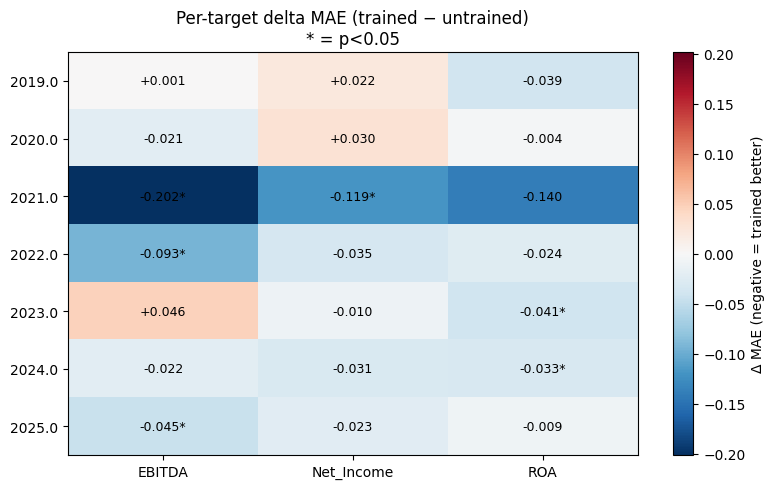

In [19]:
pivot = df_pt_sig.pivot(index="test_year", columns="target", values="mean_delta")
pivot_p = df_pt_sig.pivot(index="test_year", columns="target", values="p_value")
vmax = max(abs(pivot.values.min()), abs(pivot.values.max()))
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r",
               vmin=-vmax, vmax=vmax)
ax.set_xticks(range(pivot.shape[1]))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(pivot.shape[0]))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        p = pivot_p.values[i, j]
        sig = "*" if p < 0.05 else ""
        ax.text(j, i, f"{v:+.3f}{sig}", ha="center", va="center", fontsize=9, color="black")
ax.set_title("Per-target delta MAE (trained − untrained)\n* = p<0.05")
plt.colorbar(im, ax=ax, label="Δ MAE (negative = trained better)")
plt.tight_layout()
plt.show()


In [20]:
print("=" * 78)
print("PER-TARGET VERDICT")
print("=" * 78)
for tgt in ["EBITDA", "Net_Income", "ROA"]:
    sub = df_pt_sig[df_pt_sig["target"] == tgt].sort_values("test_year")
    print(f"\n{tgt}:")
    for _, r in sub.iterrows():
        verdict = "BEATS" if r["mean_delta"] < 0 and r["significant"] == "Y" else (
            "TIES  " if r["significant"] == "n" else "LOSES ")
        print(f"  {int(r['test_year'])}: {verdict}  "
              f"(delta {r['mean_delta']:+.4f}, p={r['p_value']:.3f})")


PER-TARGET VERDICT

EBITDA:
  2019: TIES    (delta +0.0008, p=0.935)
  2020: TIES    (delta -0.0213, p=0.097)
  2021: BEATS  (delta -0.2018, p=0.013)
  2022: BEATS  (delta -0.0931, p=0.028)
  2023: TIES    (delta +0.0462, p=0.306)
  2024: TIES    (delta -0.0216, p=0.174)
  2025: BEATS  (delta -0.0448, p=0.045)

Net_Income:
  2019: TIES    (delta +0.0215, p=0.428)
  2020: TIES    (delta +0.0298, p=0.082)
  2021: BEATS  (delta -0.1193, p=0.017)
  2022: TIES    (delta -0.0347, p=0.170)
  2023: TIES    (delta -0.0100, p=0.555)
  2024: TIES    (delta -0.0307, p=0.133)
  2025: TIES    (delta -0.0229, p=0.198)

ROA:
  2019: TIES    (delta -0.0394, p=0.288)
  2020: TIES    (delta -0.0036, p=0.872)
  2021: TIES    (delta -0.1396, p=0.053)
  2022: TIES    (delta -0.0237, p=0.534)
  2023: BEATS  (delta -0.0409, p=0.029)
  2024: BEATS  (delta -0.0326, p=0.000)
  2025: TIES    (delta -0.0093, p=0.594)


## Visualizations

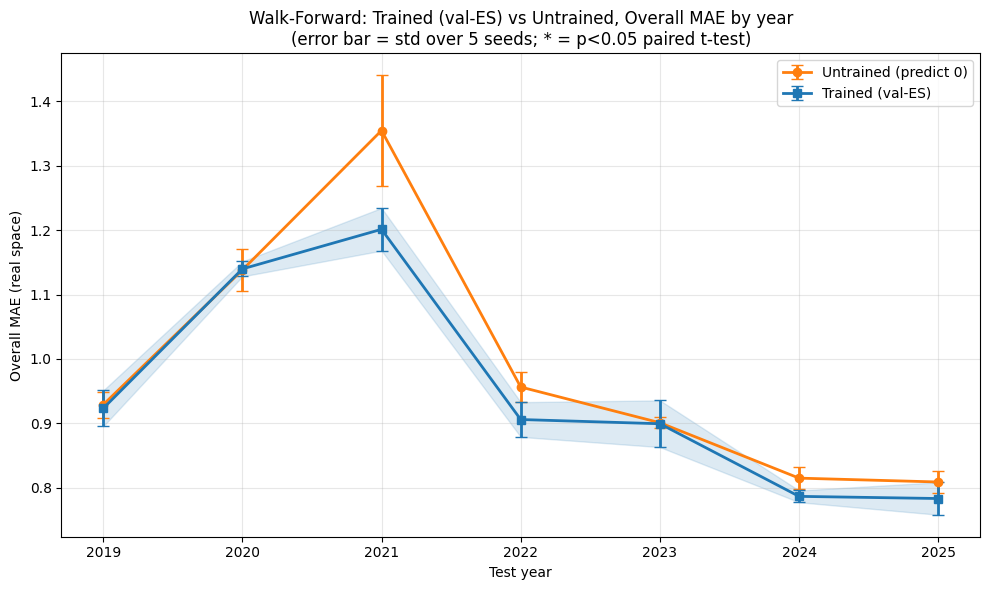

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
years = agg["test_year"].values
ax.errorbar(years, agg["untrained_mean"], yerr=agg["untrained_std"],
            marker='o', linewidth=2, capsize=4, label="Untrained (predict 0)", color='C1')
ax.errorbar(years, agg["trained_mean"], yerr=agg["trained_std"],
            marker='s', linewidth=2, capsize=4, label="Trained (val-ES)", color='C0')
ax.fill_between(years, agg["trained_mean"] - agg["trained_std"],
                agg["trained_mean"] + agg["trained_std"], alpha=0.15, color='C0')
for _, r in df_sig.iterrows():
    ax.annotate(f"{'*' if r['significant']=='Y' else ''}",
                xy=(r["test_year"], r["mean_delta"] + 0.0),
                xytext=(0, -22), textcoords='offset points',
                ha='center', fontsize=14, color='red')
ax.set_xlabel("Test year")
ax.set_ylabel("Overall MAE (real space)")
ax.set_title("Walk-Forward: Trained (val-ES) vs Untrained, Overall MAE by year\n"
             "(error bar = std over 5 seeds; * = p<0.05 paired t-test)")
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

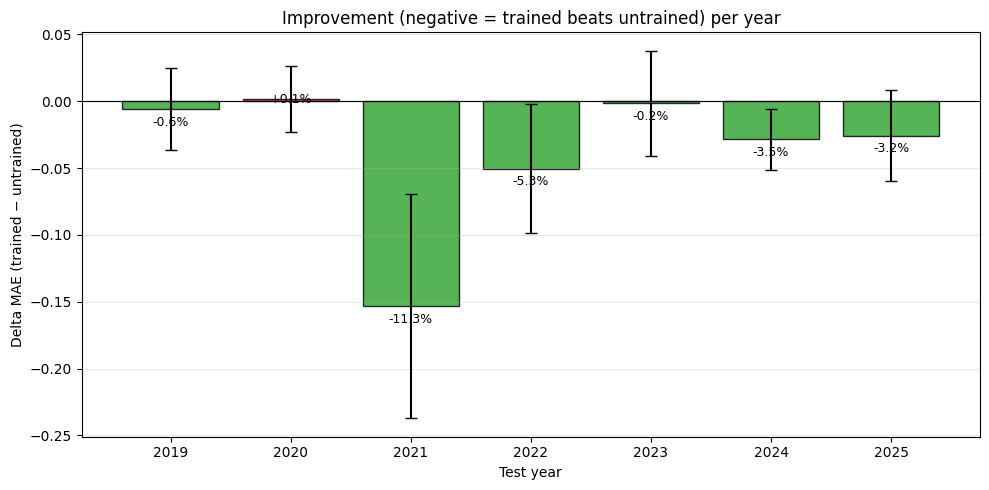

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['C2' if d < 0 else 'C3' for d in agg["delta_mean"]]
bars = ax.bar(agg["test_year"].astype(str), agg["delta_mean"],
              yerr=agg["delta_std"], capsize=4, color=colors, alpha=0.8, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel("Test year")
ax.set_ylabel("Delta MAE (trained − untrained)")
ax.set_title("Improvement (negative = trained beats untrained) per year")
for b, v in zip(bars, agg["pct_improvement"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() - 0.005,
            f"{v:+.1f}%", ha='center', va='top' if v < 0 else 'bottom',
            fontsize=9, color='black')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

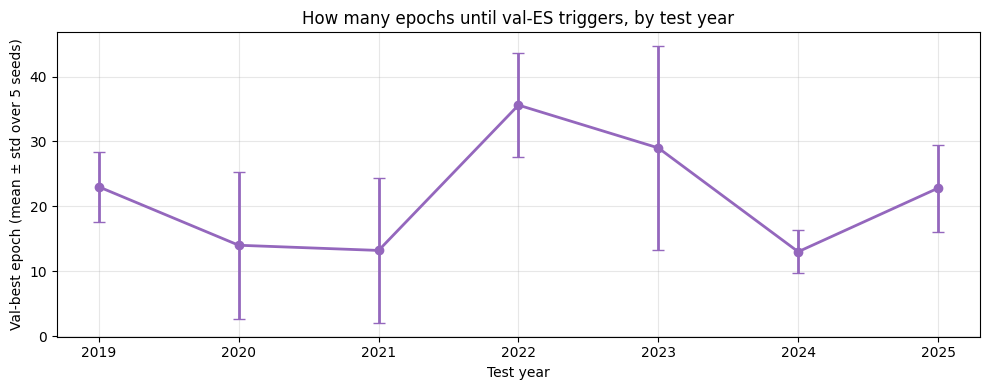

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(agg["test_year"], agg["val_best_epoch_mean"],
            yerr=agg["val_best_epoch_std"].fillna(0),
            marker='o', linewidth=2, capsize=4, color='C4')
ax.set_xlabel("Test year")
ax.set_ylabel("Val-best epoch (mean ± std over 5 seeds)")
ax.set_title("How many epochs until val-ES triggers, by test year")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Results

In [24]:
print("=" * 78)
print("WALK-FORWARD VERDICT (5 seeds, val-ES, no regularization)")
print("=" * 78)
for _, r in df_sig.iterrows():
    verdict = "BEATS" if r["mean_delta"] < 0 and r["significant"] == "Y" else \
               "TIES   " if r["significant"] == "n" else "LOSES  "
    pct = 100.0 * r["mean_delta"] / agg.loc[agg["test_year"] == r["test_year"], "untrained_mean"].values[0]
    print(f"  Test {int(r['test_year'])}: trained {verdict} untrained  "
          f"(delta {r['mean_delta']:+.4f}, {pct:+.1f}%, p={r['p_value']:.3f})")

n_help = ((df_sig["mean_delta"] < 0) & (df_sig["significant"] == "Y")).sum()
n_hurt = ((df_sig["mean_delta"] > 0) & (df_sig["significant"] == "Y")).sum()
n_insig = (df_sig["significant"] == "n").sum()
print()
print(f"Summary: {n_help} years help (sig), {n_hurt} years hurt (sig), {n_insig} years inconclusive.")
print()
mean_pct = 100.0 * agg["delta_mean"].mean() / agg["untrained_mean"].mean()
print(f"Mean improvement across years: {mean_pct:+.2f}% (Overall MAE)")
print(f"Best year: {int(agg.loc[agg['delta_mean'].idxmin(), 'test_year'])} "
      f"({agg['delta_mean'].min():+.4f} MAE)")
print(f"Worst year: {int(agg.loc[agg['delta_mean'].idxmax(), 'test_year'])} "
      f"({agg['delta_mean'].max():+.4f} MAE)")
if agg["delta_mean"].is_monotonic_increasing:
    print("\nDelta is monotonically increasing over time — clear signature of distribution shift.")
elif agg["delta_mean"].is_monotonic_decreasing:
    print("\nDelta is monotonically decreasing over time — trained model is improving relative to baseline.")
else:
    print("\nDelta is non-monotonic — distribution shift is not the only factor.")

WALK-FORWARD VERDICT (5 seeds, val-ES, no regularization)
  Test 2019: trained TIES    untrained  (delta -0.0057, -0.6%, p=0.698)
  Test 2020: trained TIES    untrained  (delta +0.0017, +0.1%, p=0.884)
  Test 2021: trained BEATS untrained  (delta -0.1534, -11.3%, p=0.015)
  Test 2022: trained TIES    untrained  (delta -0.0505, -5.3%, p=0.079)
  Test 2023: trained TIES    untrained  (delta -0.0016, -0.2%, p=0.933)
  Test 2024: trained TIES    untrained  (delta -0.0283, -3.5%, p=0.050)
  Test 2025: trained TIES    untrained  (delta -0.0257, -3.2%, p=0.165)

Summary: 1 years help (sig), 0 years hurt (sig), 6 years inconclusive.

Mean improvement across years: -3.82% (Overall MAE)
Best year: 2021 (-0.1534 MAE)
Worst year: 2020 (+0.0017 MAE)

Delta is non-monotonic — distribution shift is not the only factor.


## Sample Weights by Recency

In [25]:
ALPHA_VALUES = [0.5, 1.0]
print(f"Sample-weight α sweep: {ALPHA_VALUES}")
print(f"Per fold: {len(ALPHA_VALUES) * len(WALK_FORWARD_YEARS) * N_SEEDS_WF} model builds")


Sample-weight α sweep: [0.5, 1.0]
Per fold: 70 model builds


In [26]:
sw_rows = []
for alpha in ALPHA_VALUES:
    for ty in WALK_FORWARD_YEARS:
        val_year = ty - 1
        train_end_year = ty - 2
        train_df = data_df_imp[data_df_imp["year"] <= train_end_year].copy()
        val_df   = data_df_imp[data_df_imp["year"] == val_year].copy()
        test_df  = data_df_imp[data_df_imp["year"] == ty].copy()
        n_train, n_val, n_test = len(train_df), len(val_df), len(test_df)
        print(f"\n=== α={alpha} | Test year {ty} | train ≤{train_end_year} ({n_train}) ===")
        for si in range(N_SEEDS_WF):
            seed = SEED + si
            set_seed(seed)
            model, train_loader, val_loader, test_loader = build_loaders_wf(
                train_df, val_df, test_df, CONFIG, sample_alpha=alpha
            )
            untrained_res = evaluate_loader(model, test_loader)
            untrained_mae = untrained_res["Overall"]
            optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"],
                                         weight_decay=CONFIG.get("weight_decay", 0.0))
            best_val_ep, best_val_mae, test_at_best_val = train_with_val_es(
                model, train_loader, val_loader, test_loader, optimizer,
                patience=PATIENCE, max_epochs=MAX_EPOCHS, grad_clip=5.0, verbose=False,
            )
            delta = test_at_best_val - untrained_mae
            sw_rows.append({
                "alpha": alpha, "test_year": ty, "seed": seed,
                "val_best_epoch": best_val_ep,
                "untrained_mae": untrained_mae, "trained_mae": test_at_best_val,
                "delta": delta,
            })
            print(f"  seed {seed}: val_best_ep={best_val_ep:3d}  untrained={untrained_mae:.4f}  "
                  f"trained={test_at_best_val:.4f}  delta={delta:+.4f}")

df_sw = pd.DataFrame(sw_rows)
df_sw.to_csv("walk_forward_sample_weights_results.csv", index=False)
print(f"\nSaved walk_forward_sample_weights_results.csv ({len(df_sw)} rows)")



=== α=0.5 | Test year 2019 | train ≤2017 (2364) ===
  seed 42: val_best_ep= 23  untrained=0.9395  trained=1.2922  delta=+0.3527
  seed 43: val_best_ep= 25  untrained=0.9048  trained=0.9646  delta=+0.0598
  seed 44: val_best_ep= 25  untrained=0.9137  trained=0.9183  delta=+0.0046
  seed 45: val_best_ep= 24  untrained=0.9553  trained=1.1817  delta=+0.2264
  seed 46: val_best_ep= 32  untrained=0.9311  trained=1.7059  delta=+0.7748

=== α=0.5 | Test year 2020 | train ≤2018 (2739) ===
  seed 42: val_best_ep=  6  untrained=1.1858  trained=1.1592  delta=-0.0266
  seed 43: val_best_ep=  8  untrained=1.1198  trained=1.1417  delta=+0.0219
  seed 44: val_best_ep= 12  untrained=1.1105  trained=1.1598  delta=+0.0493
  seed 45: val_best_ep= 10  untrained=1.1571  trained=1.1760  delta=+0.0190
  seed 46: val_best_ep= 11  untrained=1.1173  trained=1.1768  delta=+0.0595

=== α=0.5 | Test year 2021 | train ≤2019 (3115) ===
  seed 42: val_best_ep= 13  untrained=1.3363  trained=1.1997  delta=-0.1365
  see

In [ ]:
baseline_rows = []
for _, r in df_wf.iterrows():
    baseline_rows.append({
        "alpha": 0.0, "test_year": r["test_year"], "seed": r["seed"],
        "val_best_epoch": r["val_best_epoch"],
        "untrained_mae": r["untrained_mae"], "trained_mae": r["trained_mae"],
        "delta": r["delta"],
    })
df_bl = pd.DataFrame(baseline_rows)
df_all = pd.concat([df_bl, df_sw], ignore_index=True)
print(f"α=0 baseline: {len(df_bl)} rows (from walk-forward loop above)")
print(f"α>0 runs:     {len(df_sw)} rows (from sample-weights sweep)")
print(f"Combined:     {len(df_all)} rows across α ∈ {{0.0, 0.5, 1.0}}")


α=0 baseline: 35 rows (from walk-forward loop above)
α>0 runs:     70 rows (from sample-weights sweep)
Combined:     105 rows across α ∈ {0.0, 0.5, 1.0}


In [28]:
agg_all = df_all.groupby(["alpha", "test_year"]).agg(
    n=("seed", "count"),
    delta_mean=("delta", "mean"),
    delta_std=("delta", "std"),
    trained_mean=("trained_mae", "mean"),
    untrained_mean=("untrained_mae", "mean"),
).reset_index()
agg_all["pct_improvement"] = 100.0 * agg_all["delta_mean"] / agg_all["untrained_mean"]
print("Per-(α, year) summary (5 seeds per cell):")
display(agg_all.round(4))


Per-(α, year) summary (5 seeds per cell):


,alpha,test_year,n,delta_mean,delta_std,trained_mean,untrained_mean,pct_improvement
0,0.0,2019.0,5,-0.0057,0.0306,0.9232,0.9289,-0.6154
1,0.0,2020.0,5,0.0017,0.0244,1.1398,1.1381,0.1485
2,0.0,2021.0,5,-0.1534,0.0838,1.2013,1.3548,-11.3253
3,0.0,2022.0,5,-0.0505,0.0482,0.9059,0.9564,-5.2794
4,0.0,2023.0,5,-0.0016,0.0394,0.8994,0.9010,-0.1745
5,0.0,2024.0,5,-0.0283,0.0229,0.7866,0.8149,-3.4734
6,0.0,2025.0,5,-0.0257,0.0338,0.7833,0.8089,-3.1742
7,0.5,2019.0,5,0.2837,0.3071,1.2125,0.9289,30.5383
8,0.5,2020.0,5,0.0246,0.0335,1.1627,1.1381,2.1604
9,0.5,2021.0,5,-0.1095,0.0473,1.2452,1.3548,-8.0862


In [29]:
sig_rows = []
for (a, ty), sub in df_all.groupby(["alpha", "test_year"]):
    d = sub["delta"].values
    t_stat, p_val = stats.ttest_1samp(d, popmean=0.0)
    sig = "Y" if p_val < 0.05 else "n"
    sig_rows.append({"alpha": a, "test_year": ty, "mean_delta": d.mean(),
                     "t_stat": t_stat, "p_value": p_val, "significant": sig})
df_sig = pd.DataFrame(sig_rows)

print("=" * 80)
print("Per (α, year) t-test (trained vs untrained):")
print("=" * 80)
for a in sorted(df_sig["alpha"].unique()):
    print(f"\nα = {a}:")
    sub = df_sig[df_sig["alpha"] == a].sort_values("test_year")
    for _, r in sub.iterrows():
        verdict = "BEATS" if r["mean_delta"] < 0 and r["significant"] == "Y" else "TIES  " if r["significant"] == "n" else "LOSES "
        print(f"  {int(r['test_year'])}: {verdict}  delta={r['mean_delta']:+.4f}  p={r['p_value']:.3f}")


Per (α, year) t-test (trained vs untrained):

α = 0.0:
  2019: TIES    delta=-0.0057  p=0.698
  2020: TIES    delta=+0.0017  p=0.884
  2021: BEATS  delta=-0.1534  p=0.015
  2022: TIES    delta=-0.0505  p=0.079
  2023: TIES    delta=-0.0016  p=0.933
  2024: TIES    delta=-0.0283  p=0.050
  2025: TIES    delta=-0.0257  p=0.165

α = 0.5:
  2019: TIES    delta=+0.2837  p=0.108
  2020: TIES    delta=+0.0246  p=0.176
  2021: BEATS  delta=-0.1095  p=0.007
  2022: TIES    delta=+0.0850  p=0.055
  2023: TIES    delta=+0.0060  p=0.576
  2024: BEATS  delta=-0.0245  p=0.035
  2025: TIES    delta=+0.0333  p=0.303

α = 1.0:
  2019: TIES    delta=+0.0770  p=0.055
  2020: TIES    delta=+0.0604  p=0.064
  2021: BEATS  delta=-0.1138  p=0.021
  2022: TIES    delta=+0.0187  p=0.508
  2023: TIES    delta=+0.0044  p=0.763
  2024: BEATS  delta=-0.0220  p=0.040
  2025: TIES    delta=-0.0199  p=0.102


In [ ]:

for ty in WALK_FORWARD_YEARS:
    bl = df_all[(df_all["alpha"] == 0.0) & (df_all["test_year"] == ty)].sort_values("seed")
    for a in [0.5, 1.0]:
        sw = df_all[(df_all["alpha"] == a) & (df_all["test_year"] == ty)].sort_values("seed")
        if len(bl) == 0 or len(sw) == 0: continue
        diff = (sw["delta"].values - bl["delta"].values)
        t_stat, p_val = stats.ttest_1samp(diff, popmean=0.0)
        verdict = "BETTER" if diff.mean() < 0 and p_val < 0.05 else "WORSE " if diff.mean() > 0 and p_val < 0.05 else "TIE   "
        print(f"  {int(ty)} α={a} vs α=0: {verdict}  "
              f"Δdiff={diff.mean():+.4f}  p={p_val:.3f}")


Head-to-head: does each α beat α=0 baseline on each year?
(paired t-test on per-seed delta difference; negative diff = α wins)
  2019 α=0.5 vs α=0: TIE     Δdiff=+0.2894  p=0.090
  2019 α=1.0 vs α=0: TIE     Δdiff=+0.0827  p=0.089
  2020 α=0.5 vs α=0: WORSE   Δdiff=+0.0229  p=0.009
  2020 α=1.0 vs α=0: WORSE   Δdiff=+0.0587  p=0.028
  2021 α=0.5 vs α=0: TIE     Δdiff=+0.0439  p=0.185
  2021 α=1.0 vs α=0: TIE     Δdiff=+0.0396  p=0.450
  2022 α=0.5 vs α=0: WORSE   Δdiff=+0.1355  p=0.026
  2022 α=1.0 vs α=0: TIE     Δdiff=+0.0691  p=0.139
  2023 α=0.5 vs α=0: TIE     Δdiff=+0.0076  p=0.711
  2023 α=1.0 vs α=0: TIE     Δdiff=+0.0059  p=0.532
  2024 α=0.5 vs α=0: TIE     Δdiff=+0.0038  p=0.506
  2024 α=1.0 vs α=0: TIE     Δdiff=+0.0063  p=0.246
  2025 α=0.5 vs α=0: TIE     Δdiff=+0.0590  p=0.062
  2025 α=1.0 vs α=0: TIE     Δdiff=+0.0058  p=0.734


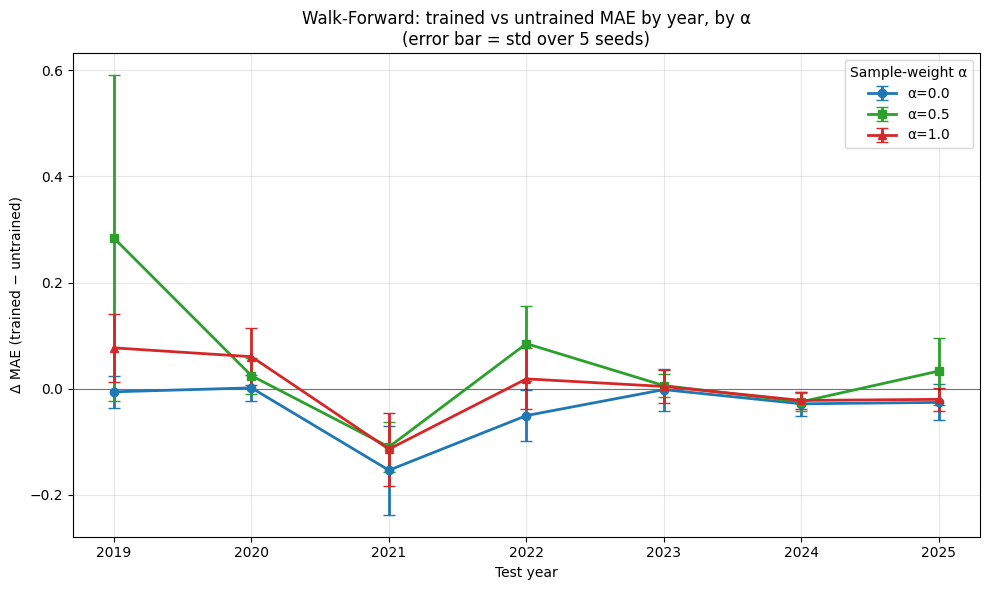

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {0.0: "C0", 0.5: "C2", 1.0: "C3"}
markers = {0.0: "o", 0.5: "s", 1.0: "^"}
for a in sorted(agg_all["alpha"].unique()):
    sub = agg_all[agg_all["alpha"] == a].sort_values("test_year")
    ax.errorbar(sub["test_year"], sub["delta_mean"], yerr=sub["delta_std"],
                marker=markers.get(a, "x"), linewidth=2, capsize=4,
                label=f"α={a}", color=colors.get(a, "gray"))
ax.axhline(0, color="black", linewidth=0.8, linestyle="-", alpha=0.5)
ax.set_xlabel("Test year")
ax.set_ylabel("Δ MAE (trained − untrained)")
ax.set_title("Walk-Forward: trained vs untrained MAE by year, by α\n(error bar = std over 5 seeds)")
ax.legend(loc="best", title="Sample-weight α")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


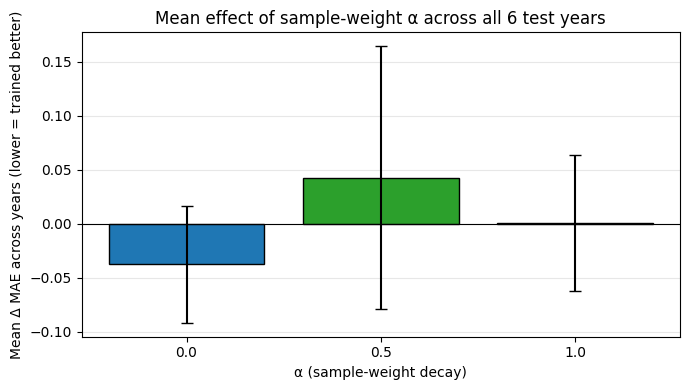

In [32]:
agg_alpha = agg_all.groupby("alpha")["delta_mean"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(agg_alpha["alpha"].astype(str), agg_alpha["mean"],
       yerr=agg_alpha["std"], capsize=4, color=["C0", "C2", "C3"], edgecolor="black")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("α (sample-weight decay)")
ax.set_ylabel("Mean Δ MAE across years (lower = trained better)")
ax.set_title("Mean effect of sample-weight α across all 6 test years")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


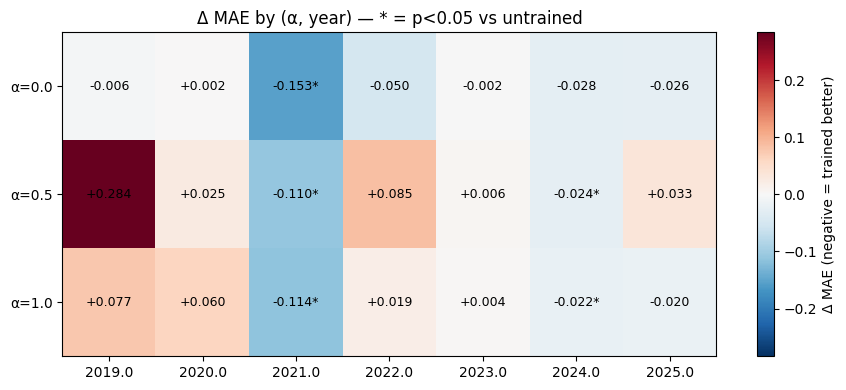

In [33]:
pivot_d = agg_all.pivot(index="alpha", columns="test_year", values="delta_mean")
pivot_p = df_sig.pivot(index="alpha", columns="test_year", values="p_value")
vmax = max(abs(pivot_d.values.min()), abs(pivot_d.values.max()))
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pivot_d.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(pivot_d.shape[1])); ax.set_xticklabels(pivot_d.columns)
ax.set_yticks(range(pivot_d.shape[0])); ax.set_yticklabels([f"α={a}" for a in pivot_d.index])
for i in range(pivot_d.shape[0]):
    for j in range(pivot_d.shape[1]):
        v = pivot_d.values[i, j]; p = pivot_p.values[i, j]
        sig = "*" if p < 0.05 else ""
        ax.text(j, i, f"{v:+.3f}{sig}", ha="center", va="center", fontsize=9)
ax.set_title("Δ MAE by (α, year) — * = p<0.05 vs untrained")
plt.colorbar(im, ax=ax, label="Δ MAE (negative = trained better)")
plt.tight_layout()
plt.show()


In [34]:
print("=" * 80)
print("SAMPLE-WEIGHTS VERDICT")
print("=" * 80)
for a in sorted(df_sig["alpha"].unique()):
    sub = df_sig[df_sig["alpha"] == a].sort_values("test_year")
    n_beats = ((sub["mean_delta"] < 0) & (sub["significant"] == "Y")).sum()
    n_loses = ((sub["mean_delta"] > 0) & (sub["significant"] == "Y")).sum()
    n_ties  = (sub["significant"] == "n").sum()
    mean_pct = 100.0 * sub["mean_delta"].mean() / agg_all.loc[agg_all["alpha"] == a, "untrained_mean"].mean()
    print(f"α={a}: {n_beats} BEATS, {n_loses} LOSES, {n_ties} TIES. Mean delta across years: {mean_pct:+.2f}%")

print()
print("Best α per year (lowest mean delta):")
for ty in WALK_FORWARD_YEARS:
    sub = agg_all[agg_all["test_year"] == ty].sort_values("delta_mean")
    best_alpha = sub.iloc[0]["alpha"]; best_delta = sub.iloc[0]["delta_mean"]
    print(f"  {int(ty)}: α={best_alpha} (delta={best_delta:+.4f})")

print()
print("Head-to-head vs α=0 (which α beats baseline at p<0.05):")
for ty in WALK_FORWARD_YEARS:
    bl = df_all[(df_all["alpha"] == 0.0) & (df_all["test_year"] == ty)].sort_values("seed")
    wins = []
    for a in [0.5, 1.0]:
        sw = df_all[(df_all["alpha"] == a) & (df_all["test_year"] == ty)].sort_values("seed")
        if len(bl) == 0 or len(sw) == 0: continue
        diff = sw["delta"].values - bl["delta"].values
        t_stat, p_val = stats.ttest_1samp(diff, popmean=0.0)
        if diff.mean() < 0 and p_val < 0.05: wins.append(f"α={a}(p={p_val:.3f})")
    if wins: print(f"  {int(ty)}: " + ", ".join(wins))
    else:   print(f"  {int(ty)}: no α beats baseline at p<0.05")


SAMPLE-WEIGHTS VERDICT
α=0.0: 1 BEATS, 0 LOSES, 6 TIES. Mean delta across years: -3.82%
α=0.5: 2 BEATS, 0 LOSES, 5 TIES. Mean delta across years: +4.33%
α=1.0: 2 BEATS, 0 LOSES, 5 TIES. Mean delta across years: +0.07%

Best α per year (lowest mean delta):
  2019: α=0.0 (delta=-0.0057)
  2020: α=0.0 (delta=+0.0017)
  2021: α=0.0 (delta=-0.1534)
  2022: α=0.0 (delta=-0.0505)
  2023: α=0.0 (delta=-0.0016)
  2024: α=0.0 (delta=-0.0283)
  2025: α=0.0 (delta=-0.0257)

Head-to-head vs α=0 (which α beats baseline at p<0.05):
  2019: no α beats baseline at p<0.05
  2020: no α beats baseline at p<0.05
  2021: no α beats baseline at p<0.05
  2022: no α beats baseline at p<0.05
  2023: no α beats baseline at p<0.05
  2024: no α beats baseline at p<0.05
  2025: no α beats baseline at p<0.05


## Target-Specific Regularization

In [35]:
class ShallowLSTMMultiHead(nn.Module):
    """Shallow LSTM with one head per target, each with its own dropout rate."""
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = 3,
                 dropout_per_target=None, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.num_targets = num_targets
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        if dropout_per_target is None:
            dropout_per_target = [0.0] * num_targets
        assert len(dropout_per_target) == num_targets, "dropout_per_target length must match num_targets"
        self.dropouts = nn.ModuleList([nn.Dropout(p=d) for d in dropout_per_target])
        self.heads = nn.ModuleList([
            nn.Linear(hidden_size + static_dim, 1) for _ in range(num_targets)
        ])

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed_x)
        hidden = hn[-1]
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = torch.cat([h(d(hidden)) for d, h in zip(self.dropouts, self.heads)], dim=-1)
        if logits.size(-1) == 1:
            logits = logits.squeeze(-1)
        return logits


In [36]:
def build_loaders_wf_multihead(train_df, val_df, test_df, params, dropout_per_target):
    mtl_train = extract_mtl_df(train_df)
    mtl_val   = extract_mtl_df(val_df)
    mtl_test  = extract_mtl_df(test_df)
    temp_sc = make_robust_scaler(mtl_train, selected_indices)
    stat_sc = fit_static_scaler(mtl_train)
    train_ds = YoYDatasetMTL(apply_static_scaler(mtl_train, stat_sc), temp_sc, selected_indices)
    val_ds   = YoYDatasetMTL(apply_static_scaler(mtl_val,   stat_sc), temp_sc, selected_indices)
    test_ds  = YoYDatasetMTL(apply_static_scaler(mtl_test,  stat_sc), temp_sc, selected_indices)
    train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True, collate_fn=collate_fn_mtl)
    val_loader   = DataLoader(val_ds,   batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    test_loader  = DataLoader(test_ds,  batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    model = ShallowLSTMMultiHead(
        len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS),
        dropout_per_target=dropout_per_target, static_dim=STATIC_DIM_IMP
    ).to(DEVICE)
    return model, train_loader, val_loader, test_loader

def train_with_val_es_per_target(model, train_loader, val_loader, test_loader, optimizer,
                                  patience=PATIENCE, max_epochs=MAX_EPOCHS, grad_clip=5.0, verbose=False):
    """Same as train_with_val_es but returns per-target test MAE at val-best epoch."""
    criterion = nn.L1Loss(reduction="none")
    best_val_mae = float("inf"); best_val_epoch = 0; best_state = None; epochs_no_improve = 0
    best_test_per_target = None
    for epoch in range(1, max_epochs + 1):
        model.train()
        for bx, by, bmask, bstatic, lengths in train_loader:
            bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(bx, lengths, bstatic)
            loss_m = criterion(logits, by)
            mask_f = bmask.to(loss_m.dtype)
            loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
            if loss.requires_grad:
                loss.backward()
                if grad_clip and grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
                optimizer.step()
        model.eval()
        va_res = evaluate_loader(model, val_loader)
        te_res = evaluate_loader(model, test_loader)
        if va_res["Overall"] < best_val_mae:
            best_val_mae = va_res["Overall"]
            best_val_epoch = epoch
            best_test_per_target = {t: te_res.get(t, None) for t in PREDICTION_TARGETS}
            best_test_overall = te_res["Overall"]
            best_state = {name: t.detach().cpu().clone() for name, t in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if verbose and (epoch % 10 == 0 or epoch == 1):
            print("    ep" + str(epoch) + " val=" + str(round(va_res['Overall'], 4)) + " test=" + str(round(te_res['Overall'], 4)))
        if epochs_no_improve >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return best_val_epoch, best_val_mae, best_test_overall, best_test_per_target


In [37]:
TSR_CONFIGS = [
    {"label": "B: all 0.2",  "dropout_per_target": [0.2, 0.2, 0.2]},
    {"label": "C: EBITDA=0.5", "dropout_per_target": [0.5, 0.0, 0.0]},
    {"label": "D: ROA=0.5",    "dropout_per_target": [0.0, 0.0, 0.5]},
]
N_SEEDS_TSR = 5
print("Target-specific reg sweep: " + str(len(TSR_CONFIGS)) + " configs x " + str(N_SEEDS_TSR) + " seeds x " + str(len(WALK_FORWARD_YEARS)) + " years = " + str(len(TSR_CONFIGS) * N_SEEDS_TSR * len(WALK_FORWARD_YEARS)) + " runs")

tsr_rows = []
for cfg in TSR_CONFIGS:
    for ty in WALK_FORWARD_YEARS:
        val_year = ty - 1
        train_end_year = ty - 2
        train_df = data_df_imp[data_df_imp["year"] <= train_end_year].copy()
        val_df   = data_df_imp[data_df_imp["year"] == val_year].copy()
        test_df  = data_df_imp[data_df_imp["year"] == ty].copy()
        n_train, n_val, n_test = len(train_df), len(val_df), len(test_df)
        print("\n=== " + cfg["label"] + " | Test year " + str(ty) + " | train <=" + str(train_end_year) + " (" + str(n_train) + ") ===")
        for si in range(N_SEEDS_TSR):
            seed = SEED + si
            set_seed(seed)
            model, train_loader, val_loader, test_loader = build_loaders_wf_multihead(
                train_df, val_df, test_df, CONFIG, dropout_per_target=cfg["dropout_per_target"],
            )
            untrained_res = evaluate_loader(model, test_loader)
            optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"],
                                         weight_decay=CONFIG.get("weight_decay", 0.0))
            best_val_ep, best_val_mae, test_overall, test_per_target = train_with_val_es_per_target(
                model, train_loader, val_loader, test_loader, optimizer,
                patience=PATIENCE, max_epochs=MAX_EPOCHS, grad_clip=5.0, verbose=False,
            )
            delta = test_overall - untrained_res["Overall"]
            row = {
                "config": cfg["label"],
                "test_year": ty, "seed": seed, "val_best_epoch": best_val_ep,
                "untrained_mae": untrained_res["Overall"],
                "trained_mae": test_overall, "delta": delta,
                "untrained_ebitda": untrained_res["EBITDA"],
                "untrained_ni":     untrained_res["Net_Income"],
                "untrained_roa":    untrained_res["ROA"],
                "trained_ebitda":   test_per_target["EBITDA"],
                "trained_ni":       test_per_target["Net_Income"],
                "trained_roa":      test_per_target["ROA"],
            }
            tsr_rows.append(row)
            ebitda_d = row["trained_ebitda"] - row["untrained_ebitda"]
            ni_d     = row["trained_ni"] - row["untrained_ni"]
            roa_d    = row["trained_roa"] - row["untrained_roa"]
            print("  seed " + str(seed) + ": val_best_ep=" + str(best_val_ep) + " overall D=" + format(delta, "+.4f") + " EBITDA D=" + format(ebitda_d, "+.4f") + " NI D=" + format(ni_d, "+.4f") + " ROA D=" + format(roa_d, "+.4f"))

df_tsr = pd.DataFrame(tsr_rows)
df_tsr.to_csv("walk_forward_target_specific_reg_results.csv", index=False)
print("\nSaved walk_forward_target_specific_reg_results.csv (" + str(len(df_tsr)) + " rows)")


Target-specific reg sweep: 3 configs x 5 seeds x 7 years = 105 runs

=== B: all 0.2 | Test year 2019 | train <=2017 (2364) ===
  seed 42: val_best_ep=27 overall D=-0.0540 EBITDA D=-0.0021 NI D=-0.0029 ROA D=-0.1562
  seed 43: val_best_ep=26 overall D=-0.0152 EBITDA D=+0.0097 NI D=+0.0015 ROA D=-0.0563
  seed 44: val_best_ep=25 overall D=-0.0400 EBITDA D=-0.0640 NI D=-0.0225 ROA D=-0.0339
  seed 45: val_best_ep=23 overall D=-0.0280 EBITDA D=+0.0565 NI D=-0.0207 ROA D=-0.1186
  seed 46: val_best_ep=16 overall D=-0.0170 EBITDA D=-0.0649 NI D=+0.0317 ROA D=-0.0187

=== B: all 0.2 | Test year 2020 | train <=2018 (2739) ===
  seed 42: val_best_ep=10 overall D=-0.0388 EBITDA D=-0.0372 NI D=+0.0110 ROA D=-0.0901
  seed 43: val_best_ep=9 overall D=-0.0036 EBITDA D=-0.0260 NI D=+0.0181 ROA D=-0.0031
  seed 44: val_best_ep=16 overall D=+0.0154 EBITDA D=+0.0095 NI D=+0.0261 ROA D=+0.0104
  seed 45: val_best_ep=14 overall D=-0.0280 EBITDA D=-0.0387 NI D=+0.0262 ROA D=-0.0717
  seed 46: val_best_ep=

In [38]:
# Reuse Config A (no reg, single head) from the existing walk-forward loop
baseline_rows = []
for _, r in df_wf.iterrows():
    baseline_rows.append({
        "config": "A: no reg (baseline)",
        "test_year": r["test_year"], "seed": r["seed"], "val_best_epoch": r["val_best_epoch"],
        "untrained_mae": r["untrained_mae"], "trained_mae": r["trained_mae"],
        "delta": r["delta"],
        "untrained_ebitda": r["untrained_ebitda"],
        "untrained_ni":     r["untrained_ni"],
        "untrained_roa":    r["untrained_roa"],
        "trained_ebitda":   r["trained_ebitda"],
        "trained_ni":       r["trained_ni"],
        "trained_roa":      r["trained_roa"],
    })
df_a = pd.DataFrame(baseline_rows)
df_tsr_all = pd.concat([df_a, df_tsr], ignore_index=True)
print("Config A (no reg) baseline:  " + str(len(df_a)) + " rows")
print("New configs (B, C, D):       " + str(len(df_tsr)) + " rows")
print("Combined:                     " + str(len(df_tsr_all)) + " rows across 4 configs")


Config A (no reg) baseline:  35 rows
New configs (B, C, D):       105 rows
Combined:                     140 rows across 4 configs


In [39]:
target_map = {"EBITDA": "ebitda", "Net_Income": "ni", "ROA": "roa"}
pt_rows_tsr = []
for _, r in df_tsr_all.iterrows():
    for tgt, short in target_map.items():
        u = r["untrained_" + short]
        t = r["trained_" + short]
        pt_rows_tsr.append({
            "config": r["config"], "test_year": r["test_year"], "target": tgt, "seed": r["seed"],
            "untrained": u, "trained": t, "delta": t - u,
        })
df_pt_tsr = pd.DataFrame(pt_rows_tsr)
agg_tsr = df_pt_tsr.groupby(["config", "test_year", "target"]).agg(
    n=("seed", "count"),
    untrained_mean=("untrained", "mean"),
    trained_mean=("trained", "mean"),
    delta_mean=("delta", "mean"),
    delta_std=("delta", "std"),
).reset_index()
agg_tsr["pct_improvement"] = 100.0 * agg_tsr["delta_mean"] / agg_tsr["untrained_mean"]
print("Per-(config, year, target) summary (5 seeds per cell):")
display(agg_tsr.round(4))


Per-(config, year, target) summary (5 seeds per cell):


,config,test_year,target,n,untrained_mean,trained_mean,delta_mean,delta_std,pct_improvement
0,A: no reg (baseline),2019.0,EBITDA,5,0.7197,0.7205,0.0008,0.0204,0.1099
1,A: no reg (baseline),2019.0,Net_Income,5,1.0166,1.0382,0.0215,0.0546,2.1192
2,A: no reg (baseline),2019.0,ROA,5,1.0469,1.0075,-0.0394,0.0719,-3.7616
3,A: no reg (baseline),2020.0,EBITDA,5,0.7720,0.7507,-0.0213,0.0221,-2.7587
4,A: no reg (baseline),2020.0,Net_Income,5,1.3169,1.3467,0.0298,0.0289,2.2651
...,...,...,...,...,...,...,...,...,...
79,D: ROA=0.5,2024.0,Net_Income,5,0.9196,0.8812,-0.0384,0.0150,-4.1795
80,D: ROA=0.5,2024.0,ROA,5,0.9563,0.8834,-0.0729,0.0760,-7.6283
81,D: ROA=0.5,2025.0,EBITDA,5,0.5590,0.5488,-0.0102,0.0694,-1.8236
82,D: ROA=0.5,2025.0,Net_Income,5,0.9876,0.9515,-0.0361,0.0642,-3.6582


In [40]:
tsr_sig = []
for (cfg, ty, tgt), sub in df_pt_tsr.groupby(["config", "test_year", "target"]):
    d = sub["delta"].values
    t_stat, p_val = stats.ttest_1samp(d, popmean=0.0)
    sig = "Y" if p_val < 0.05 else "n"
    tsr_sig.append({"config": cfg, "test_year": ty, "target": tgt,
                    "mean_delta": d.mean(), "std_delta": d.std(ddof=1),
                    "t_stat": t_stat, "p_value": p_val, "significant": sig})
df_tsr_sig = pd.DataFrame(tsr_sig)

print("=" * 80)
print("Per-(config, year, target) t-test (trained vs untrained):")
print("=" * 80)
for cfg in sorted(df_tsr_sig["config"].unique()):
    print("\n" + cfg + ":")
    sub = df_tsr_sig[df_tsr_sig["config"] == cfg].sort_values(["target", "test_year"])
    for _, r in sub.iterrows():
        verdict = "BEATS" if r["mean_delta"] < 0 and r["significant"] == "Y" else "TIES  " if r["significant"] == "n" else "LOSES "
        yr = int(r["test_year"])
        tg = r["target"]
        md = r["mean_delta"]
        pv = r["p_value"]
        print("  " + str(yr) + " " + tg + ": " + verdict + " delta=" + format(md, "+.4f") + " p=" + format(pv, ".3f"))

print()
n_sig_total = (df_tsr_sig["significant"] == "Y").sum()
print("Total significant wins across all (config, year, target) cells: " + str(n_sig_total) + "/" + str(len(df_tsr_sig)))


Per-(config, year, target) t-test (trained vs untrained):

A: no reg (baseline):
  2019 EBITDA: TIES   delta=+0.0008 p=0.935
  2020 EBITDA: TIES   delta=-0.0213 p=0.097
  2021 EBITDA: BEATS delta=-0.2018 p=0.013
  2022 EBITDA: BEATS delta=-0.0931 p=0.028
  2023 EBITDA: TIES   delta=+0.0462 p=0.306
  2024 EBITDA: TIES   delta=-0.0216 p=0.174
  2025 EBITDA: BEATS delta=-0.0448 p=0.045
  2019 Net_Income: TIES   delta=+0.0215 p=0.428
  2020 Net_Income: TIES   delta=+0.0298 p=0.082
  2021 Net_Income: BEATS delta=-0.1193 p=0.017
  2022 Net_Income: TIES   delta=-0.0347 p=0.170
  2023 Net_Income: TIES   delta=-0.0100 p=0.555
  2024 Net_Income: TIES   delta=-0.0307 p=0.133
  2025 Net_Income: TIES   delta=-0.0229 p=0.198
  2019 ROA: TIES   delta=-0.0394 p=0.288
  2020 ROA: TIES   delta=-0.0036 p=0.872
  2021 ROA: TIES   delta=-0.1396 p=0.053
  2022 ROA: TIES   delta=-0.0237 p=0.534
  2023 ROA: BEATS delta=-0.0409 p=0.029
  2024 ROA: BEATS delta=-0.0326 p=0.000
  2025 ROA: TIES   delta=-0.0093 p=

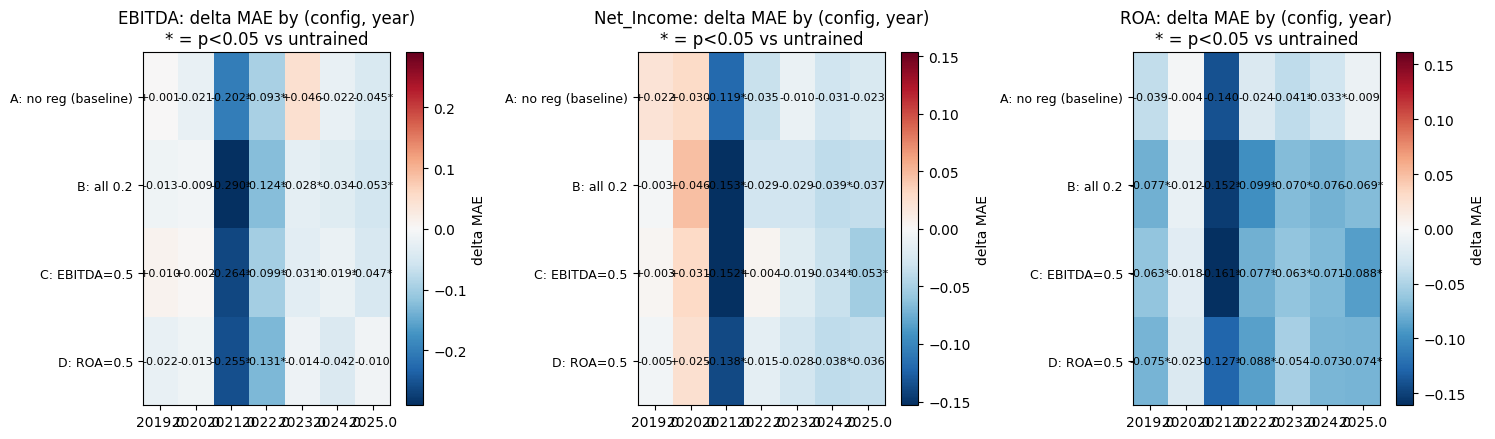

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, tgt in zip(axes, ["EBITDA", "Net_Income", "ROA"]):
    sub = df_tsr_sig[df_tsr_sig["target"] == tgt]
    pivot_d = sub.pivot(index="config", columns="test_year", values="mean_delta")
    pivot_p = sub.pivot(index="config", columns="test_year", values="p_value")
    vmax = max(abs(np.nanmin(pivot_d.values)), abs(np.nanmax(pivot_d.values)))
    im = ax.imshow(pivot_d.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(pivot_d.shape[1])); ax.set_xticklabels(pivot_d.columns)
    ax.set_yticks(range(pivot_d.shape[0])); ax.set_yticklabels(pivot_d.index, fontsize=9)
    for i in range(pivot_d.shape[0]):
        for j in range(pivot_d.shape[1]):
            v = pivot_d.values[i, j]; p = pivot_p.values[i, j]
            sig = "*" if p < 0.05 else ""
            ax.text(j, i, format(v, "+.3f") + sig, ha="center", va="center", fontsize=8)
    ax.set_title(tgt + ": delta MAE by (config, year)\n* = p<0.05 vs untrained")
    plt.colorbar(im, ax=ax, label="delta MAE")
plt.tight_layout()
plt.show()


In [42]:
print("=" * 80)
print("TARGET-SPECIFIC REGULARIZATION VERDICT")
print("=" * 80)

print("\nNumber of significant wins per config (across 18 year x target cells):")
for cfg in sorted(df_tsr_sig["config"].unique()):
    sub = df_tsr_sig[df_tsr_sig["config"] == cfg]
    n_beats = ((sub["mean_delta"] < 0) & (sub["significant"] == "Y")).sum()
    n_loses = ((sub["mean_delta"] > 0) & (sub["significant"] == "Y")).sum()
    n_ties  = (sub["significant"] == "n").sum()
    print("  " + cfg + ": " + str(n_beats) + " BEATS, " + str(n_loses) + " LOSES, " + str(n_ties) + " TIES")

print("\nBest config per (year, target) cell:")
for (ty, tgt), sub in df_tsr_sig.groupby(["test_year", "target"]):
    best_idx = sub["mean_delta"].idxmin()
    best = sub.loc[best_idx]
    yr = int(ty)
    print("  " + str(yr) + " " + tgt + ": best = " + best["config"] + " (delta=" + format(best["mean_delta"], "+.4f") + ", p=" + format(best["p_value"], ".3f") + ")")

print("\nKey question answers:")
# B vs A: does multi-head architecture help (focus on EBITDA)?
a_ebitda = df_tsr_sig[(df_tsr_sig["config"] == "A: no reg (baseline)") & (df_tsr_sig["target"] == "EBITDA")]["mean_delta"].mean()
b_ebitda = df_tsr_sig[(df_tsr_sig["config"] == "B: all 0.2") & (df_tsr_sig["target"] == "EBITDA")]["mean_delta"].mean()
a_roa    = df_tsr_sig[(df_tsr_sig["config"] == "A: no reg (baseline)") & (df_tsr_sig["target"] == "ROA")]["mean_delta"].mean()
d_roa    = df_tsr_sig[(df_tsr_sig["config"] == "D: ROA=0.5") & (df_tsr_sig["target"] == "ROA")]["mean_delta"].mean()

ebitda_msg = "helps" if b_ebitda < a_ebitda else "HURTS"
roa_msg = "helps" if d_roa < a_roa else "HURTS"
print("  Multi-head architecture itself (B vs A, EBITDA only):")
print("    A: " + format(a_ebitda, "+.4f") + "  B: " + format(b_ebitda, "+.4f") + "  -> " + ebitda_msg)
print("  Heavy reg on ROA (D vs A, ROA only):")
print("    A: " + format(a_roa, "+.4f") + "  D: " + format(d_roa, "+.4f") + "  -> " + roa_msg)


TARGET-SPECIFIC REGULARIZATION VERDICT

Number of significant wins per config (across 18 year x target cells):
  A: no reg (baseline): 6 BEATS, 0 LOSES, 15 TIES
  B: all 0.2: 11 BEATS, 0 LOSES, 10 TIES
  C: EBITDA=0.5: 13 BEATS, 0 LOSES, 8 TIES
  D: ROA=0.5: 8 BEATS, 0 LOSES, 13 TIES

Best config per (year, target) cell:
  2019 EBITDA: best = D: ROA=0.5 (delta=-0.0220, p=0.200)
  2019 Net_Income: best = D: ROA=0.5 (delta=-0.0046, p=0.660)
  2019 ROA: best = B: all 0.2 (delta=-0.0767, p=0.043)
  2020 EBITDA: best = A: no reg (baseline) (delta=-0.0213, p=0.097)
  2020 Net_Income: best = D: ROA=0.5 (delta=+0.0246, p=0.084)
  2020 ROA: best = D: ROA=0.5 (delta=-0.0232, p=0.377)
  2021 EBITDA: best = B: all 0.2 (delta=-0.2904, p=0.026)
  2021 Net_Income: best = B: all 0.2 (delta=-0.1532, p=0.001)
  2021 ROA: best = C: EBITDA=0.5 (delta=-0.1609, p=0.006)
  2022 EBITDA: best = D: ROA=0.5 (delta=-0.1311, p=0.022)
  2022 Net_Income: best = A: no reg (baseline) (delta=-0.0347, p=0.170)
  2022 RO